## Customer Churn Prediction

##### Problem Statement: Predicting Customer Churn from a Telecom dataset to assist in customer retention
This Jupyter notebook has complete EDA and model pipeline

Other features in this project:
1. Live Streamlit app
2. GitHub repo
3. Project documentation
4. SHAP explainability plots


## Phase 1 — EDA + Preprocessing + Feature Engineering 

In [1]:
import pandas as pd

data = pd.read_csv('C:/Users/Aashi Khanna/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1/WA_Fn-UseC_-Telco-Customer-Churn.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
numOfCustomers = len(data)
numOfCustomers

7043

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
data = data.drop(columns=['customerID'])
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
data.select_dtypes(include='object').nunique()

gender                 2
Partner                2
Dependents             2
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
TotalCharges        6531
Churn                  2
dtype: int64

In [6]:
data.select_dtypes(include='object').apply(lambda x: x.unique())
#analyzing all unique values of features with dtype = object

gender                                                 [Female, Male]
Partner                                                     [Yes, No]
Dependents                                                  [No, Yes]
PhoneService                                                [No, Yes]
MultipleLines                             [No phone service, No, Yes]
InternetService                                [DSL, Fiber optic, No]
OnlineSecurity                         [No, Yes, No internet service]
OnlineBackup                           [Yes, No, No internet service]
DeviceProtection                       [No, Yes, No internet service]
TechSupport                            [No, Yes, No internet service]
StreamingTV                            [No, Yes, No internet service]
StreamingMovies                        [No, Yes, No internet service]
Contract                         [Month-to-month, One year, Two year]
PaperlessBilling                                            [Yes, No]
PaymentMethod       

In [7]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges']
#converting Total Charges to a numeric datatype instead of object

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [8]:
data.isnull().sum()
#finding number of null entries in each column

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
data.dropna(subset=['TotalCharges'], inplace=True)
#dropping null entries with respect to the Total Charges column

In [10]:
data.shape
#final shape of cleaned data (7034 - 11 rows, and the removed customerID column)

(7032, 20)

In [11]:
data['TotalCharges'].isnull().sum()

0

In [12]:
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

In [13]:
X = data.drop(columns=['Churn'])
y = data['Churn']

In [14]:
X.shape

(7032, 19)

In [15]:
y.value_counts()

0    5163
1    1869
Name: Churn, dtype: int64

7 columns have "No service" fields. Eg- TechSupport : No internet service => No tech support.
Hence, collapse all "No service" fields to "No". Followed by binary encoding, since only two labels (Yes/No). 

In [16]:
no_service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

X[no_service_cols] = X[no_service_cols].replace({'No internet service': 'No', 'No phone service': 'No'})
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90
7040,Female,0,Yes,Yes,11,No,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60


In [17]:
X.select_dtypes(include='object').apply(lambda x: x.unique())

gender                                                 [Female, Male]
Partner                                                     [Yes, No]
Dependents                                                  [No, Yes]
PhoneService                                                [No, Yes]
MultipleLines                                               [No, Yes]
InternetService                                [DSL, Fiber optic, No]
OnlineSecurity                                              [No, Yes]
OnlineBackup                                                [Yes, No]
DeviceProtection                                            [No, Yes]
TechSupport                                                 [No, Yes]
StreamingTV                                                 [No, Yes]
StreamingMovies                                             [No, Yes]
Contract                         [Month-to-month, One year, Two year]
PaperlessBilling                                            [Yes, No]
PaymentMethod       

In [18]:
#label encoding binary columns 
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 
               'OnlineBackup', 'DeviceProtection', 'TechSupport', 
               'StreamingTV', 'StreamingMovies', 
               'PaperlessBilling']

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in binary_cols:
    X[col] = le.fit_transform(X[col])
    
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85
1,1,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50
2,1,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15
3,1,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75
4,0,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65


In [19]:
#one hot encoding the categorical columns (multiple labels)
# eg : Contract is broken into two columns - One year and Two year with labels (0,1). Month-to-month will be denoted if both One year and Two year columnns are 0.

X = pd.get_dummies(X, columns=['Contract', 'InternetService', 'PaymentMethod'], drop_first=True)
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,1,29.85,29.85,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,0,56.95,1889.50,1,0,0,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,1,53.85,108.15,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,0,42.30,1840.75,1,0,0,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,1,70.70,151.65,0,0,1,0,0,1,0


In [20]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7032 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int32  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int32  
 3   Dependents                             7032 non-null   int32  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int32  
 6   MultipleLines                          7032 non-null   int32  
 7   OnlineSecurity                         7032 non-null   int32  
 8   OnlineBackup                           7032 non-null   int32  
 9   DeviceProtection                       7032 non-null   int32  
 10  TechSupport                            7032 non-null   int32  
 11  Stre

In [21]:
X.shape

(7032, 23)

In [22]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
X_train.shape

(5625, 23)

In [24]:
y_train.shape

(5625,)

In [25]:
X_test.shape

(1407, 23)

In [26]:
y_test.shape

(1407,)

In [27]:
#scaling the numeric (float) columns, ones with a magnitude 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols]) #calibrate on train data
X_test[num_cols] = scaler.transform(X_test[num_cols]) #use already calibrate scaler on train data

In [28]:
X_train[num_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,5.625000e+03,5.625000e+03,5.625000e+03
mean,-1.557273e-16,1.025451e-16,2.861908e-18
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.286145e+00,-1.547843e+00,-1.003365e+00
25%,-9.601500e-01,-9.698847e-01,-8.301191e-01
50%,-1.451620e-01,1.860324e-01,-3.918414e-01
75%,9.550717e-01,8.320837e-01,6.591681e-01
max,1.607062e+00,1.782062e+00,2.805224e+00


In [29]:
import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [30]:
#check class distribution in y_train

y_train.value_counts(normalize="True")*100

0    73.422222
1    26.577778
Name: Churn, dtype: float64

In [31]:
#extremely uneven distribution : only 26% churn cases
#handle class imbalance using SMOTE (Synthetic Minority Over-sampling Technique)
!pip install imblearn
import imblearn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [32]:
y_train_sm.value_counts()

0    4130
1    4130
Name: Churn, dtype: int64

In [33]:
y_train_sm.value_counts(normalize="true")*100

0    50.0
1    50.0
Name: Churn, dtype: float64

SMOTE creates synthetic churn examples by interpolating between real ones, bringing your training data to a 50/50 balance.

In [34]:
X_train_sm.shape

(8260, 23)

## Phase 2 - Model Training, Testing and Tuning

Model Flow: Logistic Regression -> Random Forest -> XGBoost


- To find out the churn probability, we need a baseline like Logistic Regression. 
- Random Forest then handles outliers and non-linear relationships. 
- XGBoost builds trees sequentially and corrects error, industry benchmark for structured tabular data. It also offers high explainabilty, which we need to determine the cause of churn. 

We then compare all models to rule out the best one.

Metrics : Accuracy, Precision, Recall, AUC-ROC

(Most important metrics for our business problem are Recall and AUC-ROC. Refer docs for explanation.)

In [35]:
#logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_sm, y_train_sm)

lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1] #prob of churn class 1

print("Logistic Regression Results")
print(f"Accuracy:  {accuracy_score(y_test, lr_preds):.4f}")
print(f"Precision: {precision_score(y_test, lr_preds):.4f}")
print(f"Recall:    {recall_score(y_test, lr_preds):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, lr_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds))

Logistic Regression Results
Accuracy:  0.7456
Precision: 0.5148
Recall:    0.7433
AUC-ROC:   0.8277

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1033
           1       0.51      0.74      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.75      0.76      1407



In [36]:
#random forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_sm, y_train_sm)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print(f"Accuracy:  {accuracy_score(y_test, rf_preds):.4f}")
print(f"Precision: {precision_score(y_test, rf_preds):.4f}")
print(f"Recall:    {recall_score(y_test, rf_preds):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, rf_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds))

Random Forest Results
Accuracy:  0.7711
Precision: 0.5602
Recall:    0.6471
AUC-ROC:   0.8155

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1033
           1       0.56      0.65      0.60       374

    accuracy                           0.77      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.78      0.77      0.78      1407



In [37]:
!pip install xgboost
import xgboost as xgb

In [38]:
#XGBoost

from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_sm, y_train_sm)

xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Results")
print(f"Accuracy:  {accuracy_score(y_test, xgb_preds):.4f}")
print(f"Precision: {precision_score(y_test, xgb_preds):.4f}")
print(f"Recall:    {recall_score(y_test, xgb_preds):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, xgb_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds))

XGBoost Results
Accuracy:  0.7655
Precision: 0.5478
Recall:    0.6738
AUC-ROC:   0.8094

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.80      0.83      1033
           1       0.55      0.67      0.60       374

    accuracy                           0.77      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.77      0.77      1407



In [39]:
#tuned XGBoost

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=1,
    verbose=1
)

xgb_grid.fit(X_train_sm, y_train_sm)

print("Best Parameters:", xgb_grid.best_params_)
print("Best CV AUC-ROC:", xgb_grid.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best CV AUC-ROC: 0.8946034555644317


In [40]:
best_xgb = xgb_grid.best_estimator_

best_xgb_preds = best_xgb.predict(X_test)
best_xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

print("Tuned XGBoost Results")
print(f"Accuracy:  {accuracy_score(y_test, best_xgb_preds):.4f}")
print(f"Precision: {precision_score(y_test, best_xgb_preds):.4f}")
print(f"Recall:    {recall_score(y_test, best_xgb_preds):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, best_xgb_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, best_xgb_preds))

Tuned XGBoost Results
Accuracy:  0.7470
Precision: 0.5181
Recall:    0.6872
AUC-ROC:   0.8212

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.77      0.82      1033
           1       0.52      0.69      0.59       374

    accuracy                           0.75      1407
   macro avg       0.69      0.73      0.70      1407
weighted avg       0.78      0.75      0.76      1407



In [41]:
#tuned LR
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=1,
    verbose=1
)

lr_grid.fit(X_train_sm, y_train_sm)

print("Best Parameters:", lr_grid.best_params_)
print("Best CV AUC-ROC:", lr_grid.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'saga'}
Best CV AUC-ROC: 0.8895908693842374


In [42]:
best_lr = lr_grid.best_estimator_

best_lr_preds = best_lr.predict(X_test)
best_lr_probs = best_lr.predict_proba(X_test)[:, 1]

print("Tuned Logistic Regression Results")
print(f"Accuracy:  {accuracy_score(y_test, best_lr_preds):.4f}")
print(f"Precision: {precision_score(y_test, best_lr_preds):.4f}")
print(f"Recall:    {recall_score(y_test, best_lr_preds):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, best_lr_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, best_lr_preds))

Tuned Logistic Regression Results
Accuracy:  0.7534
Precision: 0.5258
Recall:    0.7353
AUC-ROC:   0.8268

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1033
           1       0.53      0.74      0.61       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.75      0.76      1407



In [43]:
import pandas as pd
from sklearn.metrics import recall_score, roc_auc_score

# Example:
# Replace these with your actual model names and predictions

models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "Tuned XGBoost": best_xgb,
    "Tuned Logistic Regression": best_lr
}

# True labels
# y_test = actual target values

results = []

for name, model in models.items():
    
    # Predicted class labels
    y_pred = model.predict(X_test)
    
    # Predicted probabilities for positive class
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    recall = recall_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_prob)
    
    # Store results
    results.append({
        "Model": name,
        "Recall": round(recall, 4),
        "AUC-ROC": round(auc_roc, 4)
    })

# Create comparison table
results_df = pd.DataFrame(results)

# Sort by AUC-ROC (optional)
results_df = results_df.sort_values(by="AUC-ROC", ascending=False)

# Display table
print(results_df)

                       Model  Recall  AUC-ROC
0        Logistic Regression  0.7433   0.8277
4  Tuned Logistic Regression  0.7353   0.8268
3              Tuned XGBoost  0.6872   0.8212
1              Random Forest  0.6471   0.8155
2                    XGBoost  0.6738   0.8094


In [44]:
import joblib

joblib.dump(lr_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X_train.columns), 'columns.pkl')

['columns.pkl']

In [45]:
import os
print(os.path.exists('model.pkl'))
print(os.path.exists('scaler.pkl'))
print(os.path.exists('columns.pkl'))

True
True
True


## Phase 3 - SHAP Analysis

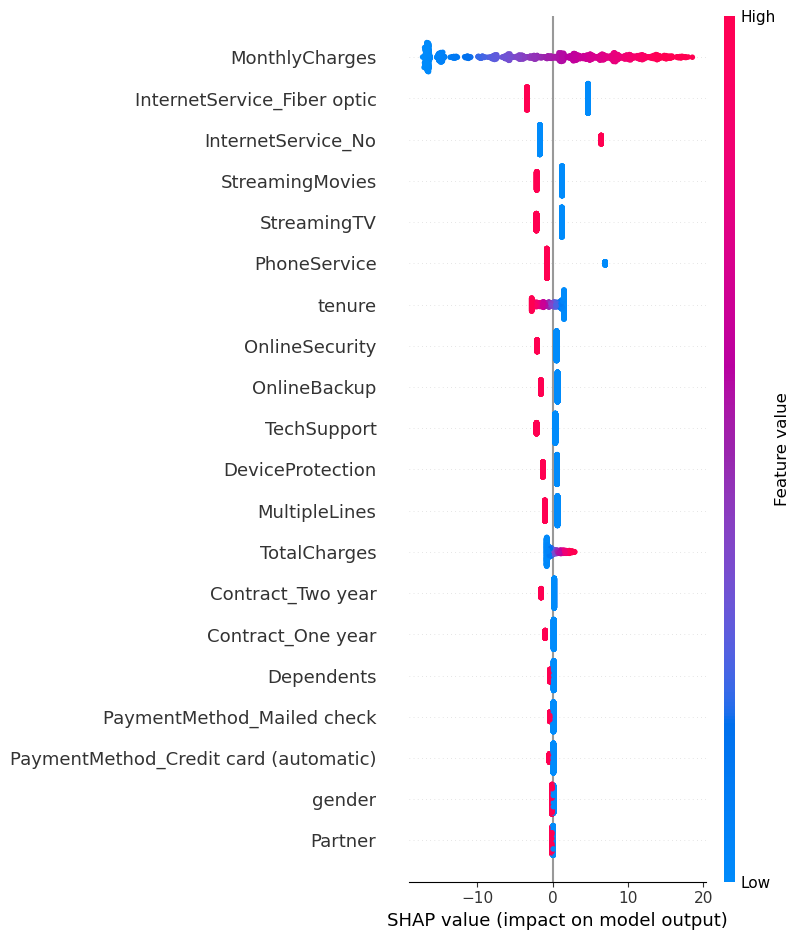

In [46]:
import shap

explainer = shap.LinearExplainer(best_lr, X_train_sm)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=list(X_test.columns))

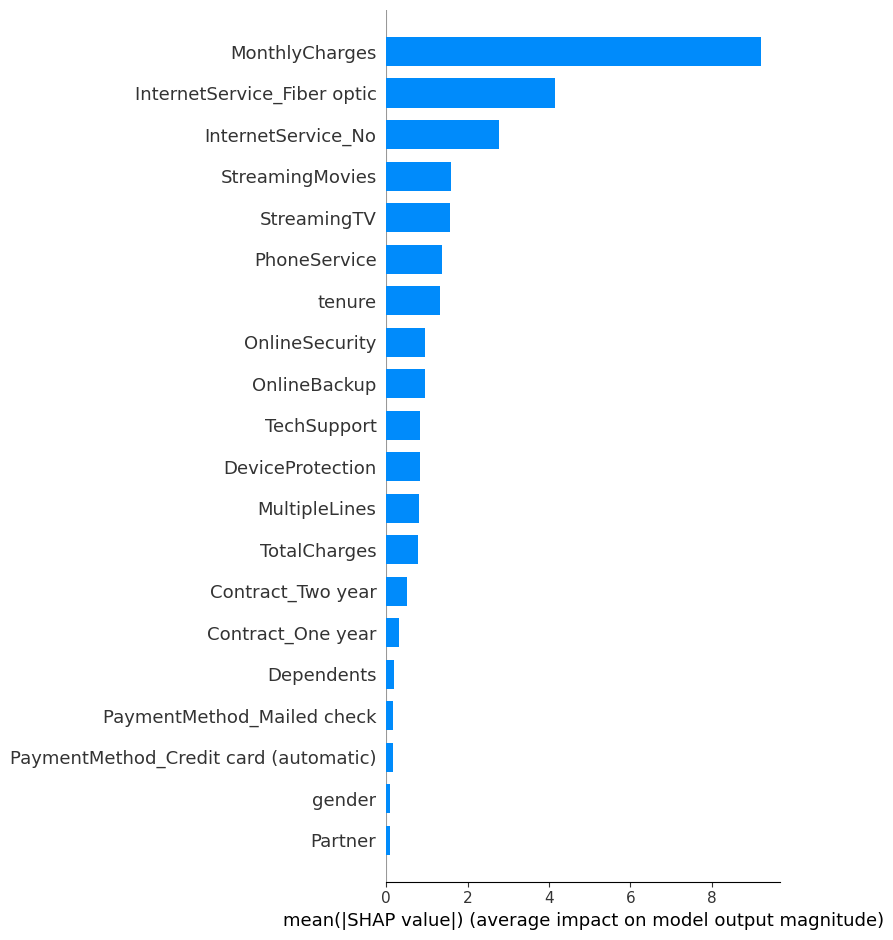

In [47]:
shap.summary_plot(shap_values, X_test, 
                  feature_names=list(X_test.columns), 
                  plot_type='bar')

In [48]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
shap.summary_plot(shap_values, X_test, 
                  feature_names=list(X_test.columns),
                  plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.close()

fig, ax = plt.subplots()
shap.summary_plot(shap_values, X_test,
                  feature_names=list(X_test.columns),
                  show=False)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.close()

In [49]:
print(os.path.exists('shap_bar.png'))
print(os.path.exists('shap_beeswarm.png'))

True
True


Metric Curves

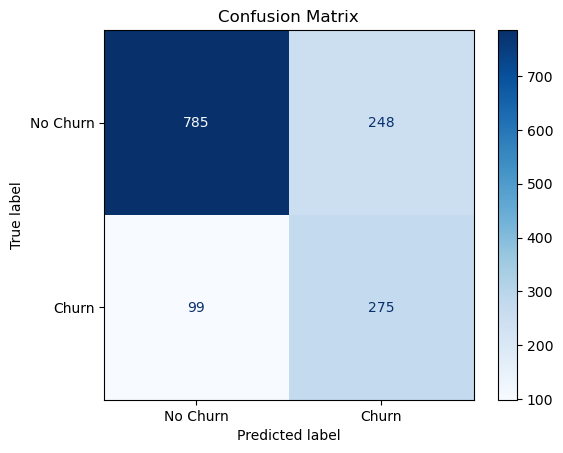

In [50]:
#Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(best_lr, X_test, y_test, 
                                       display_labels=['No Churn', 'Churn'],
                                       cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

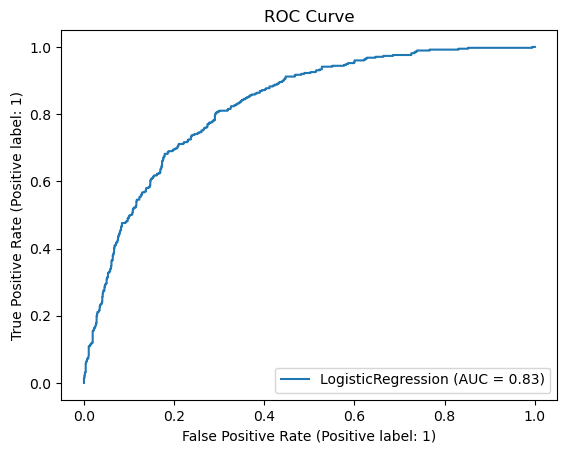

In [51]:
#ROC Curve (area under the curve = AUC-ROC)
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_lr, X_test, y_test)
plt.title('ROC Curve')
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

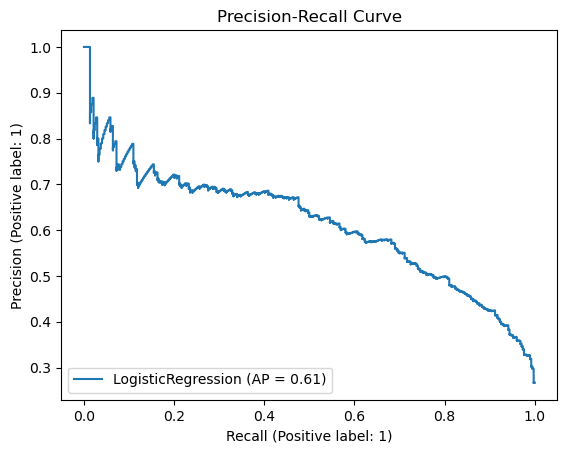

In [52]:
#Precision Recall Curve
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(best_lr, X_test, y_test)
plt.title('Precision-Recall Curve')
plt.savefig('precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

EDA insight plots

1. Churn Rate by Contract Type

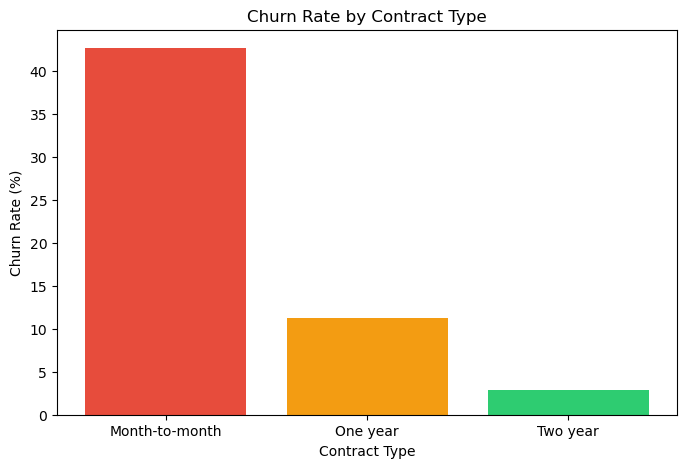

In [53]:
contract_churn = data.groupby('Contract')['Churn'].mean().reset_index()
contract_churn['Churn'] = contract_churn['Churn'] * 100

plt.figure(figsize=(8,5))
plt.bar(contract_churn['Contract'], contract_churn['Churn'], color=['#e74c3c','#f39c12','#2ecc71'])
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
plt.savefig('churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

2. Churn rate by tenure group

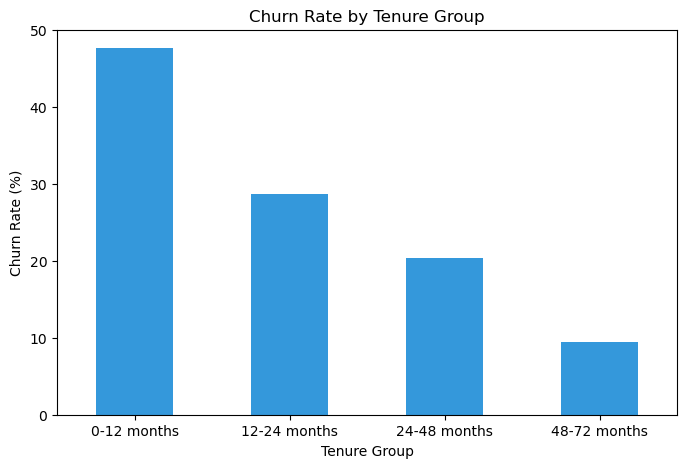

In [54]:
data['tenure_group'] = pd.cut(data['tenure'], 
                               bins=[0,12,24,48,72], 
                               labels=['0-12 months','12-24 months','24-48 months','48-72 months'])

tenure_churn = data.groupby('tenure_group')['Churn'].mean() * 100

plt.figure(figsize=(8,5))
tenure_churn.plot(kind='bar', color='#3498db', rot=0)
plt.title('Churn Rate by Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Tenure Group')
plt.savefig('churn_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

3. Monthly charges distribution by Churn

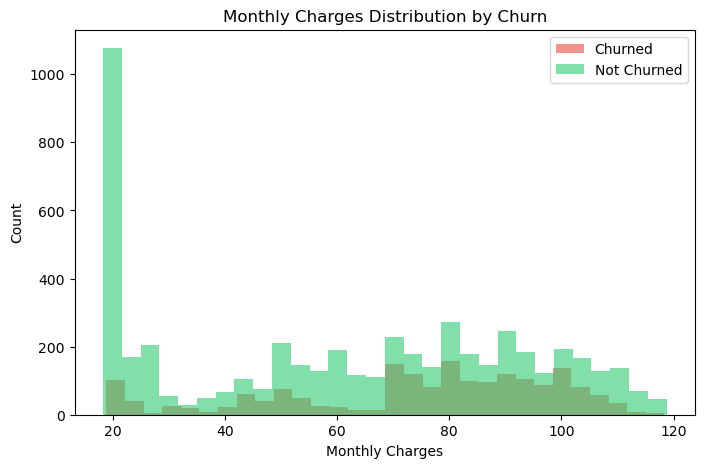

In [55]:
plt.figure(figsize=(8,5))
plt.hist(data[data['Churn']==1]['MonthlyCharges'], bins=30, 
         alpha=0.6, label='Churned', color='#e74c3c')
plt.hist(data[data['Churn']==0]['MonthlyCharges'], bins=30, 
         alpha=0.6, label='Not Churned', color='#2ecc71')
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('Count')
plt.legend()
plt.savefig('monthly_charges_dist.png', dpi=150, bbox_inches='tight')
plt.show()

In [56]:
import os
files = ['shap_bar.png', 'shap_beeswarm.png', 'confusion_matrix.png', 
         'roc_curve.png', 'precision_recall_curve.png',
         'churn_by_contract.png', 'churn_by_tenure.png', 
         'monthly_charges_dist.png']

for f in files:
    print(f"{f}: {'exists' if os.path.exists(f) else 'MISSING'}")

shap_bar.png: exists
shap_beeswarm.png: exists
confusion_matrix.png: exists
roc_curve.png: exists
precision_recall_curve.png: exists
churn_by_contract.png: exists
churn_by_tenure.png: exists
monthly_charges_dist.png: exists
